# QDC evaluation for BARRA and NatHERS
Evaluating output from step2_qdc_scaling applying QDC to BARRA-R2/C2 using NatHERS data as observations.

In [1]:
import xarray as xr
import numpy as np
import glob
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import utils
sys.path.append('/home/565/dh4185/mn51-dh4185/repos_collab/nesp_bff/')
import utils

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xclim/sdba.py:12: UserWarning: The `xclim.sdba` module has been split into its own package `xsdba`. Users are encouraged to use `xsdba` directly. For the time being, `xclim.sdba` will import `xsdba` to allow for API compatibility. This behaviour may change in the future. For more information, see: https://xsdba.readthedocs.io/en/stable/xclim_migration_guide.html
  warnings.warn(


In [11]:
# --- Settings ---
root_dir = "/g/data/eg3/nesp_bff/"
loc = "Melbourne"
barra_version = "BARRA-R2"
cities = ["Melbourne", "Darwin", "Cairns","Brisbane","Longreach","Mildura","Adelaide","Perth","Sydney","Canberra","Hobart"]
variables = ["rsds", "rsdsdir", "sfcWind","tas","huss","psl","clt"]
variables_rsds = ["rsds", "rsdsdir"]
var = "tas"

In [3]:
# --- Read data ---
# NatHERS
ds_nathers = xr.open_dataset(glob.glob(f"{root_dir}/NatHERS/raw_data/{loc}_*_NatHERS_1990-2015.nc")[0])
offset = pd.to_timedelta(ds_nathers.coords["time_offset"].item(), unit="h")
ds_nathers_local = ds_nathers.copy()
ds_nathers_local = ds_nathers.assign_coords(time=ds_nathers["time"] + offset)#.sel(time=slice("1990","2014"))

ds_nathers_local = ds_nathers_local.assign(clt=ds_nathers_local.clt.clip(0,100))
ds_nathers_local

<xarray.Dataset> Size: 38MB
Dimensions:                 (time: 227904)
Coordinates:
    lat                     float64 8B ...
    lon                     float64 8B ...
    time_offset             float64 8B 10.0
    round_method            float64 8B ...
  * time                    (time) datetime64[ns] 2MB 1990-01-01 ... 2015-12-...
Data variables: (12/20)
    tas                     (time) float64 2MB ...
    huss                    (time) float64 2MB ...
    psl                     (time) float64 2MB ...
    sfcWind                 (time) float64 2MB ...
    wind_dir                (time) float64 2MB ...
    flag-tas                (time) float64 2MB ...
    ...                      ...
    slr_alt                 (time) float64 2MB ...
    slr_azm                 (time) float64 2MB ...
    flag-rsds               (time) float64 2MB ...
    flag-rsdsdif            (time) float64 2MB ...
    flag-rsdsdir            (time) float64 2MB ...
    clt                     (time) float64 2MB 12.5 12.5 25.0 ... 100.0 100.0

In [4]:
# BARRA raw
ds_barra_raw = xr.open_dataset(f"{root_dir}step1_raw_data_extraction/{barra_version}/{loc}_"
                                   f"AUS-11_ERA5_historical_hres_BOM_{barra_version}_v1_1hr_"
                                   f"1985-2014.nc")#.sel(time=slice("1990","2014")).load()
ds_barra_raw_time_utc = pd.to_datetime(ds_barra_raw.time.values).tz_localize('UTC')
ds_barra_raw_time_utc_to_local = ds_barra_raw_time_utc.tz_convert(f'Australia/{loc}').tz_localize(None)
ds_barra_raw_local = ds_barra_raw.copy()
ds_barra_raw_local = ds_barra_raw_local.assign_coords(time=ds_barra_raw_time_utc_to_local)
ds_barra_raw_local = utils.fix_duplicate_times(ds_barra_raw_local)
ds_barra_raw_local



Found 30 duplicate time entries.
Duplicates removed.


<xarray.Dataset> Size: 23MB
Dimensions:  (time: 262938)
Coordinates:
    lat      float64 8B ...
    lon      float64 8B ...
    crs      int32 4B ...
  * time     (time) datetime64[ns] 2MB 1985-01-01T11:00:00 ... 2015-01-01T10:...
Data variables:
    tas      (time) float64 2MB ...
    hurs     (time) float64 2MB ...
    huss     (time) float64 2MB ...
    sfcWind  (time) float64 2MB ...
    psl      (time) float64 2MB ...
    uas      (time) float64 2MB ...
    vas      (time) float64 2MB ...
    clt      (time) float64 2MB ...
    rsds     (time) float64 2MB ...
    rsdsdir  (time) float64 2MB ...

In [5]:
# --- Adjust BARRA raw data as done for QDC input ---
# Calcualte pressure at station level
ds_barra_raw_local = ds_barra_raw_local.assign(psl=utils.convert_sea_level_pressure_to_station_pressure(
                                ds_barra_raw_local.psl, utils.locations[loc]["Elev"]))

# Bin cloud area fraction into discrete classes
barra_clt_clip = ds_barra_raw_local.clt.clip(0, 100)

bins = np.array([0, 12.5, 25, 37.5, 50., 62.5, 75, 87.5, 100., 112.5])
def assign_to_left_bin(x, bins):
    """Assign each x to its left bin edge."""
    idx = np.digitize(x, bins, right=False) - 1  # shift to get left edge index
    idx = np.clip(idx, 0, len(bins) - 2)         # prevent overflow
    return bins[idx]

# Apply with vectorization and dask support
barra_clt_binned = xr.apply_ufunc(
    assign_to_left_bin,
    barra_clt_clip,
    kwargs={"bins": bins},
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
    )
ds_barra_raw_local = ds_barra_raw_local.assign(clt=barra_clt_binned)

In [6]:
# BARRA adjusted
ds_barra_adj = xr.open_dataset(f"{root_dir}step2_qdc_scaling/{barra_version}/{loc}_AUS-11_ERA5_historical_hres_BOM_"
                         f"{barra_version}_v1_1hr_1990-2014_QDC-NatHERS_TESTclt.nc")
ds_barra_adj

<xarray.Dataset> Size: 14MB
Dimensions:       (time: 219119)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1990-01-01T11:00:00 ... 2015-01-0...
    lat           float64 8B ...
    lon           float64 8B ...
    crs           int32 4B ...
    time_offset   float64 8B ...
    round_method  float64 8B ...
Data variables:
    tas           (time) float64 2MB ...
    huss          (time) float64 2MB ...
    sfcWind       (time) float64 2MB ...
    psl           (time) float64 2MB ...
    clt           (time) float64 2MB ...
    rsds          (time) float64 2MB ...
    rsdsdir       (time) float64 2MB ...

In [7]:
# Align by time
nathers, barra_raw, barra_adj = xr.align(ds_nathers_local, ds_barra_raw_local, ds_barra_adj, join="inner")
print(nathers, barra_raw, barra_adj)

<xarray.Dataset> Size: 37MB
Dimensions:                 (time: 219119)
Coordinates:
  * time                    (time) datetime64[ns] 2MB 1990-01-01T11:00:00 ......
    lat                     float64 8B ...
    lon                     float64 8B ...
    time_offset             float64 8B 10.0
    round_method            float64 8B ...
Data variables: (12/20)
    tas                     (time) float64 2MB ...
    huss                    (time) float64 2MB ...
    psl                     (time) float64 2MB ...
    sfcWind                 (time) float64 2MB ...
    wind_dir                (time) float64 2MB ...
    flag-tas                (time) float64 2MB ...
    ...                      ...
    slr_alt                 (time) float64 2MB ...
    slr_azm                 (time) float64 2MB ...
    flag-rsds               (time) float64 2MB ...
    flag-rsdsdif            (time) float64 2MB ...
    flag-rsdsdir            (time) float64 2MB ...
    clt                     (time) float64 2

rsds       | Raw RMSE=108.231, MAE=54.370, Bias=11.924 
rsdsdir    | Raw RMSE=196.848, MAE=102.132, Bias=-46.274 


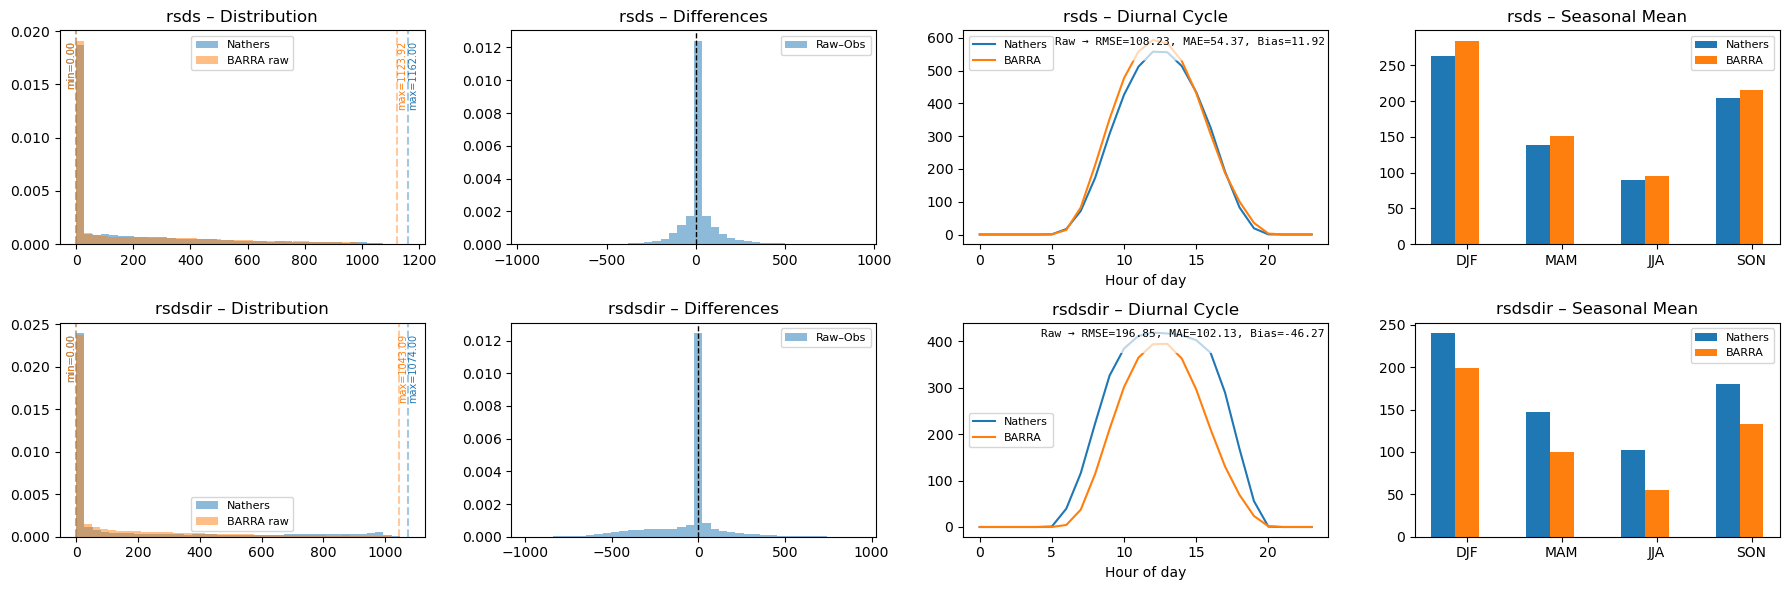

In [13]:
# Prepare figure layout
nvars = len(variables_rsds)
fig, axes = plt.subplots(nvars, 4, figsize=(18, 3 * nvars))
fig.subplots_adjust(hspace=0.4, wspace=0.25)

def compute_metrics(obs, model):
    diff = model - obs
    rmse = np.sqrt(((diff) ** 2).mean().item())
    mae = np.abs(diff).mean().item()
    bias = diff.mean().item()
    return rmse, mae, bias

for i, var in enumerate(variables_rsds):
    obs = nathers[var]
    raw = barra_raw[var]
    # adj = barra_adj[var]

    # Clip unrealistic radiation values
    if var in ["rsds", "rsdsdir"]:
        obs = obs.clip(max=1370)
        raw = raw.clip(max=1370)
        # adj = adj.clip(max=1370)

    # Ensure consistent time index
    # obs, raw, adj = xr.align(obs, raw, adj, join="inner")
    obs, raw = xr.align(obs, raw, join="inner")

    # --- 1. Distribution Comparison ---
    ax = axes[i, 0]
    ax.hist(obs, bins=40, alpha=0.5, label="Nathers", density=True)
    ax.hist(raw, bins=40, alpha=0.5, label="BARRA raw", density=True)
    # ax.hist(adj, bins=40, alpha=0.5, label="BARRA adj", density=True)
    ax.set_title(f"{var} – Distribution")

    # Add min/max annotations
    for data, color, label in zip(
        # [obs, raw, adj], ["C0", "C1", "C2"], ["Nathers", "BARRA raw", "BARRA adj"]
        [obs, raw], ["C0", "C1"], ["Nathers", "BARRA"]

    ):
        dmin, dmax = data.min().item(), data.max().item()
        ax.axvline(dmin, color=color, linestyle="--", alpha=0.4)
        ax.axvline(dmax, color=color, linestyle="--", alpha=0.4)
        ax.text(dmin, ax.get_ylim()[1]*0.95, f"min={dmin:.2f}", color=color, rotation=90,
                va="top", ha="right", fontsize=7)
        ax.text(dmax, ax.get_ylim()[1]*0.95, f"max={dmax:.2f}", color=color, rotation=90,
                va="top", ha="left", fontsize=7)
    ax.legend(fontsize=8)

    # --- 2. Histogram of Differences ---
    ax = axes[i, 1]
    diff_raw = (raw - obs).values
    # diff_adj = (adj - obs).values
    ax.hist(diff_raw, bins=40, alpha=0.5, label="Raw–Obs", density=True)
    # ax.hist(diff_adj, bins=40, alpha=0.5, label="Adj–Obs", density=True)
    ax.axvline(0, color="k", linestyle="--", linewidth=1)

    # Add min/max lines for differences
    # for diff, color, label in zip([diff_raw, diff_adj], ["C1", "C2"], ["Raw–Obs", "Adj–Obs"]):
    for diff, color, label in zip([diff_raw], ["C1"], ["Raw–Obs"]):
        dmin, dmax = np.min(diff), np.max(diff)
        ax.axvline(dmin, color=color, linestyle=":", alpha=0.5)
        ax.axvline(dmax, color=color, linestyle=":", alpha=0.5)
        ax.text(dmin, ax.get_ylim()[1]*0.9, f"{dmin:.2f}", color=color, rotation=90,
                va="top", ha="right", fontsize=7)
        ax.text(dmax, ax.get_ylim()[1]*0.9, f"{dmax:.2f}", color=color, rotation=90,
                va="top", ha="left", fontsize=7)
    ax.set_title(f"{var} – Differences")
    ax.legend(fontsize=8)

    # --- 3. Diurnal Cycle Comparison ---
    obs_hour = obs.groupby(obs["time"].dt.hour).mean()
    raw_hour = raw.groupby(raw["time"].dt.hour).mean()
    # adj_hour = adj.groupby(adj["time"].dt.hour).mean()

    ax = axes[i, 2]
    ax.plot(obs_hour["hour"], obs_hour, label="Nathers")
    ax.plot(raw_hour["hour"], raw_hour, label="BARRA")# raw")
    # ax.plot(adj_hour["hour"], adj_hour, label="BARRA adj")
    ax.set_title(f"{var} – Diurnal Cycle")
    ax.set_xlabel("Hour of day")
    ax.legend(fontsize=8)

    # --- Compute metrics ---
    rmse_raw, mae_raw, bias_raw = compute_metrics(obs, raw)
    # rmse_adj, mae_adj, bias_adj = compute_metrics(obs, adj)

    # Annotate metrics inside diurnal panel
    metrics_text = (
        f"Raw → RMSE={rmse_raw:.2f}, MAE={mae_raw:.2f}, Bias={bias_raw:.2f}\n"
        # f"Adj → RMSE={rmse_adj:.2f}, MAE={mae_adj:.2f}, Bias={bias_adj:.2f}"
    )
    ax.text(
        0.99, 0.97, metrics_text,
        transform=ax.transAxes,
        va="top", ha="right",
        fontsize=8, family="monospace",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.2")
    )

    # --- 4. Seasonal Statistics (bar plot version) ---
    obs_season = obs.groupby(obs["time"].dt.season).mean()
    raw_season = raw.groupby(raw["time"].dt.season).mean()
    # adj_season = adj.groupby(adj["time"].dt.season).mean()

    # Order seasons consistently
    seasons = ["DJF", "MAM", "JJA", "SON"]
    obs_vals = [obs_season.sel(season=s).item() for s in seasons]
    raw_vals = [raw_season.sel(season=s).item() for s in seasons]
    # adj_vals = [adj_season.sel(season=s).item() for s in seasons]

    ax = axes[i, 3]
    x = np.arange(len(seasons))
    width = 0.25
    ax.bar(x - width, obs_vals, width, label="Nathers")
    ax.bar(x, raw_vals, width, label="BARRA")# raw")
    # ax.bar(x + width, adj_vals, width, label="BARRA adj")
    ax.set_xticks(x)
    ax.set_xticklabels(seasons)
    ax.set_title(f"{var} – Seasonal Mean")
    ax.legend(fontsize=8)

    # --- Print metrics to console ---
    print(f"{var:10s} | Raw RMSE={rmse_raw:.3f}, MAE={mae_raw:.3f}, Bias={bias_raw:.3f} ")
          # f"| Adj RMSE={rmse_adj:.3f}, MAE={mae_adj:.3f}, Bias={bias_adj:.3f}")

# Clean titles for top row
# for j, title in enumerate(["Distribution", "Diff Histogram", "Diurnal", "Seasonal"]):
#     axes[0, j].set_title(title, fontweight="bold")

plt.tight_layout()
# plt.savefig(f"{root_dir}plots/{loc}_eval_QDC-BARRA-R2_NatHERS_testclt.pdf",dpi=300)
plt.show()
